In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import io
import math

## Load the Dataset: UCI Heart Disease

For this assignment, you will be using the [UCI Machine Learning Repository — Heart Disease Dataset](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data).

This dataset was collected at the Cleveland Clinic Foundation, and it contains clinical and diagnostic measurements
for patients who underwent coronary angiography, along with a binary label indicating the presence or absence of heart disease. Below is a description of a relevant subset of the features in this data:


### Features

| Feature | Description | Type |
|---|---|---|
| `age` | Age in years | numeric |
| `sex` | Sex (1 = male, 0 = female) | binary |
| `cp` | Chest pain type (0–3) | ordinal |
| `trestbps` | Resting blood pressure (mmHg) | numeric |
| `chol` | Serum cholesterol (mg/dl) | numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl | binary |
| `thalach` | Maximum heart rate achieved | numeric |
| `exang` | Exercise-induced angina | binary |
| `target` | **Heart disease present** (`target > 0` → 1) | binary |

### Privacy context

Each row represents a real, identified patient record. Fields like age, sex, and resting
blood pressure are quasi-identifiers, which viewed in aggregate, can be used to re-identify individuals
against external databases. This makes the dataset a suitable testbed for understanding differential privacy.

In [2]:
def _load_from_github():
    GITHUB_URL = (
    "https://raw.githubusercontent.com/"
    "sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
    )
    with urllib.request.urlopen(GITHUB_URL) as r:
        df = pd.read_csv(io.StringIO(r.read().decode()))

    return df, "target"

In [3]:
df, target_col = _load_from_github()
true_responses = (df["target"] > 0).astype(int).values
n_patients     = len(true_responses)
disease_rate   = float(np.mean(true_responses))
print(f"There are {n_patients} patients, with a heart disease prevalence of {disease_rate:.3f}")

There are 303 patients, with a heart disease prevalence of 0.545


## The Laplace Mechanism

We will enforce DP using the **Laplace mechanism**, a classical method of central differential privacy.
Recall that under a central DP mechanism, instead of releasing the true query answer, we instead
release a noisy version of it, which will avoid leaking information about individuals
that can be used to identify them. Concretely:


For a query $f : \mathcal{D}^n \to \mathbb{R}$ with **global sensitivity**

$$\Delta f = \max_{D \sim D'} |f(D) - f(D')|,$$

the Laplace mechanism yields a noisy estimate:

$$M(D) = f(D) + \eta, \qquad \eta \sim \mathrm{Lap}\!\left(\frac{\Delta f}{\varepsilon}\right)$$

and satisfies $\varepsilon$-differential privacy. As seen above, the mechanism introduces Laplace-distributed noise ($\eta$) with scale equal to the global sensitivity divided by the privacy parameter. In other words, the scale is $\lambda = \frac{\Delta f}{\varepsilon}$.


In this assignment, we are interested computing the prevalence of heart disease in the dataset. We define the query function as:

 $$f(D) = \frac{1}{n}\sum_{i=1}^n X_i$$

where $X_i \in \{ 0,1 \}$ indicates whether individual $i$ has heart disease. Instead of releasing the exact value of $f(D)$, which may compromise privacy, we will instead release the noisy estimate, $M(D)$.




## Part 1: Implementing the Laplace Mechanism

Implement the `laplace_mechanism` function below.

In [4]:
def laplace_mechanism(true_data, epsilon):
    """
    Releases a differentially private estimate of the prevalence
    using the Laplace mechanism.

    Steps:
      1. Compute the true prevalence f(D) = mean(true_data).
      2. Compute the global sensitivity: Delta_f = 1 / n.
      3. Draw noise eta ~ Laplace(loc=0, scale=Delta_f / epsilon).
      4. Return f(D) + eta, clipped to the valid range [0, 1].

    Args:
        true_data : array of true binary values (0 or 1), shape (n,)
        epsilon   : privacy parameter (epsilon > 0; larger = less private)

    Returns:
        noisy_estimate : float, the differentially private prevalence estimate
    """
    n = len(true_data)

    # TODO: implement Laplace mechanism
    true_prevalence = np.mean(true_data)
    delta_f = 1 / n
    scale = delta_f / epsilon
    noise = np.random.laplace(loc=0, scale=scale)
    noisy_estimate = true_prevalence + noise
    noisy_estimate = np.clip(noisy_estimate, 0, 1)

    return noisy_estimate

## Part 2: Verifying Theoretical Properties of the Mechanism

In this part, you will empirically verify two key theoretical properties of the mechanism.

**Large $\varepsilon$ recovers the true prevalence:** \
As $\varepsilon \to \infty$ the Laplace noise scales $\lambda = \Delta f / \varepsilon \to 0$, which means the added noise becomes negligible and the mechanism output should approach the true query: $M(D) \to f(D)$.

**Task**: \
Run the mechanism with `epsilon=10000`, and verify that the noisy estimate close (within $10^{-3}$) to the true mean (`np.mean(true_responses)`).

**Unbiasedness.** \
Since the Laplace noise has mean zero ($\mathrm{E}[\eta] = 0$), the mechanism is unbiased, which implies $\mathrm{E}[M(D)] = f(D)$.

**Task**: \
Run 1000 independent trials (each with its own random seed) and compute the avarage of the noisy reponses and verify that the
mean of the estimates is within 0.005 of the true rate.

In [5]:
# Check A: large epsilon → near-zero noise
np.random.seed(0)
est_large_eps = laplace_mechanism(true_responses, epsilon=10000)
true_rate     = np.mean(true_responses)

assert abs(est_large_eps - true_rate) < 1e-3, (
    f"Expected estimate ≈ {true_rate:.4f}, got {est_large_eps:.4f}. "
    "With epsilon=10000 the noise should be negligible."
)
print(f"Check A passed: estimate = {est_large_eps:.6f}, true = {true_rate:.6f}")

# Check B: unbiasedness over 1000 trials
trial_estimates = []
for seed in range(1000):
    np.random.seed(seed)
    trial_estimates.append(laplace_mechanism(true_responses, epsilon=1.0))

mean_of_estimates = np.mean(trial_estimates)

assert abs(mean_of_estimates - true_rate) < 0.005, (
    f"Mean of 1000 estimates = {mean_of_estimates:.4f}, "
    f"true rate = {true_rate:.4f}. "
    "The mechanism should be unbiased."
)
print(f"Check B passed: mean of 1000 estimates = {mean_of_estimates:.6f}, "
      f"true = {true_rate:.6f}")

Check A passed: estimate = 0.544554, true = 0.544554
Check B passed: mean of 1000 estimates = 0.544363, true = 0.544554


## Part 3: Exploring the role of $\varepsilon$

In Part 2, you verified that the Laplace mechanism is unbiased and that larger $\varepsilon$ reduces noise. In this part, we will explore how the privacy budget $\varepsilon$ controls the variability (noise) in the output. In some sense, you can think of $\varepsilon$ as a knob: turning it **down** enforces *more privacy* at the cost of *more noise* and turning it **up** allows *weaker privacy* but with *less noise* added.


For each $\varepsilon$ in `epsilon_values`, run **100 independent trials**.
In each trial apply `laplace_mechanism` and record the estimate.

After all 100 trials for a given $\varepsilon$, store the **mean** and **standard deviation**
of the estimates in dictionary indexed by $\varepsilon$:

```python
results[epsilon] = {'mean': ..., 'std': ...}
```

**Hint**: \
To ensure reproducibility and independence across trials, make sure you call `np.random.seed(seed)` in the inner loop and use a different seed for each trial.

In [6]:
# TODO: run the trials and get estimates
results = {}

# choose epsilon values 
epsilon_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]

for epsilon in epsilon_values:
    
    estimates = []
    
    for seed in range(100):
        np.random.seed(seed)  
        est = laplace_mechanism(true_responses, epsilon)
        estimates.append(est)
    
    mean_est = np.mean(estimates)
    std_est = np.std(estimates)
    
    results[epsilon] = {
        'mean': float(mean_est),
        'std': float(std_est)
    }


## Part 4: Privacy-Utility Tradeoff

In this part, we will visualize how utilty changes as a function of our privacy budget. Recall that the stronger privacy we want (smaller $\varepsilon$), the more noise we need, which degrades the accuracy, that is, how close the noisy estimate $M(D)$ is to the true query value, $f(D)$. The degredation of the accuracy is directly related to utility: if the estimate is highly inaccurate, then any model built using it would also likely suffer in performance, lowering its utility.

Use the helper function below to plot **utility** ($1/\text{variance}$) against $\log_{10}(\varepsilon)$.

We use a log scale for $\varepsilon$ because the values span several orders of magnitude
(0.001 to 5.0). We will also use $1/\text{variance}$ to measure utilty, since variance measures how unstable or noisy our estimate is, and the higher the variance, the lower the utility, and vice versa.

  Annotate each point with its $\varepsilon$ value and the theoretical
noise standard deviation $\sigma = \sqrt{2}\,\Delta f / \varepsilon = \sqrt{2}/(n\varepsilon)$.

In [7]:
def plot_laplace_tradeoff(epsilon_values, results, n, disease_rate):
    """
    Plots the privacy-utility tradeoff for the Laplace mechanism.

    Args:
        epsilon_values : list of epsilon values used in the simulation
        results        : dict mapping epsilon -> {'mean': float, 'std': float}
        n              : dataset size (used for theoretical curve)
        disease_rate   : true prevalence (used for reference line)
    """
    eps_arr = np.array(epsilon_values)
    std_arr = np.array([results[e]['std'] for e in epsilon_values])
    utility = 1.0 / std_arr**2   # 1/variance

    # theoretical noise std: sqrt(2) * (1/n) / epsilon
    eps_theory = np.logspace(np.log10(eps_arr.min()), np.log10(eps_arr.max()), 200)
    std_theory = np.sqrt(2) / (n * eps_theory)
    util_theory = 1.0 / std_theory**2

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    ax.plot(np.log10(eps_theory), util_theory, '--', color='steelblue',
            linewidth=2, label='Theoretical $1/\sigma^2$')
    ax.plot(np.log10(eps_arr), utility, 'o', color='#e74c3c', markersize=10,
            markeredgecolor='black', zorder=5, label='Simulated $1/\sigma^2$')

    for eps, u, s in zip(eps_arr, utility, std_arr):
        ax.annotate(f'ε={eps}\nσ={s:.4f}',
                    xy=(np.log10(eps), u),
                    xytext=(np.log10(eps) + 0.15, u * 1.05),
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))

    ax.set_xlabel(r'$\log_{10}(\varepsilon)$', fontsize=13)
    ax.set_ylabel(r'Utility  $(1/\sigma^2)$', fontsize=13)
    ax.set_title('Privacy–Utility Tradeoff\n(Laplace Mechanism)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    means = [results[e]['mean'] for e in epsilon_values]
    stds  = std_arr

    ax2.errorbar(np.log10(eps_arr), means, yerr=1.96*stds,
                 fmt='o-', color='#e74c3c', capsize=5, linewidth=2,
                 markersize=8, markeredgecolor='black', label='Estimate ± 1.96σ')
    ax2.axhline(disease_rate, color='steelblue', linestyle='--',
                linewidth=2, label=f'True rate ({disease_rate:.4f})')

    ax2.set_xlabel(r'$\log_{10}(\varepsilon)$', fontsize=13)
    ax2.set_ylabel('Estimated Prevalence', fontsize=13)
    ax2.set_title('Estimates vs. True Rate\n(Laplace Mechanism)', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
/var/folders/w1/8lfbg3cd3ml7pllccmlw3zvh0000gn/T/ipykernel_19206/3489840229.py:24: SyntaxWarning: invalid escape sequence '\s'
  linewidth=2, label='Theoretical $1/\sigma^2$')
/var/folders/w1/8lfbg3cd3ml7pllccmlw3zvh0000gn/T/ipykernel_19206/3489840229.py:26: SyntaxWarning: invalid escape sequence '\s'
  markeredgecolor='black', zorder=5, label='Simulated $1/\sigma^2$')


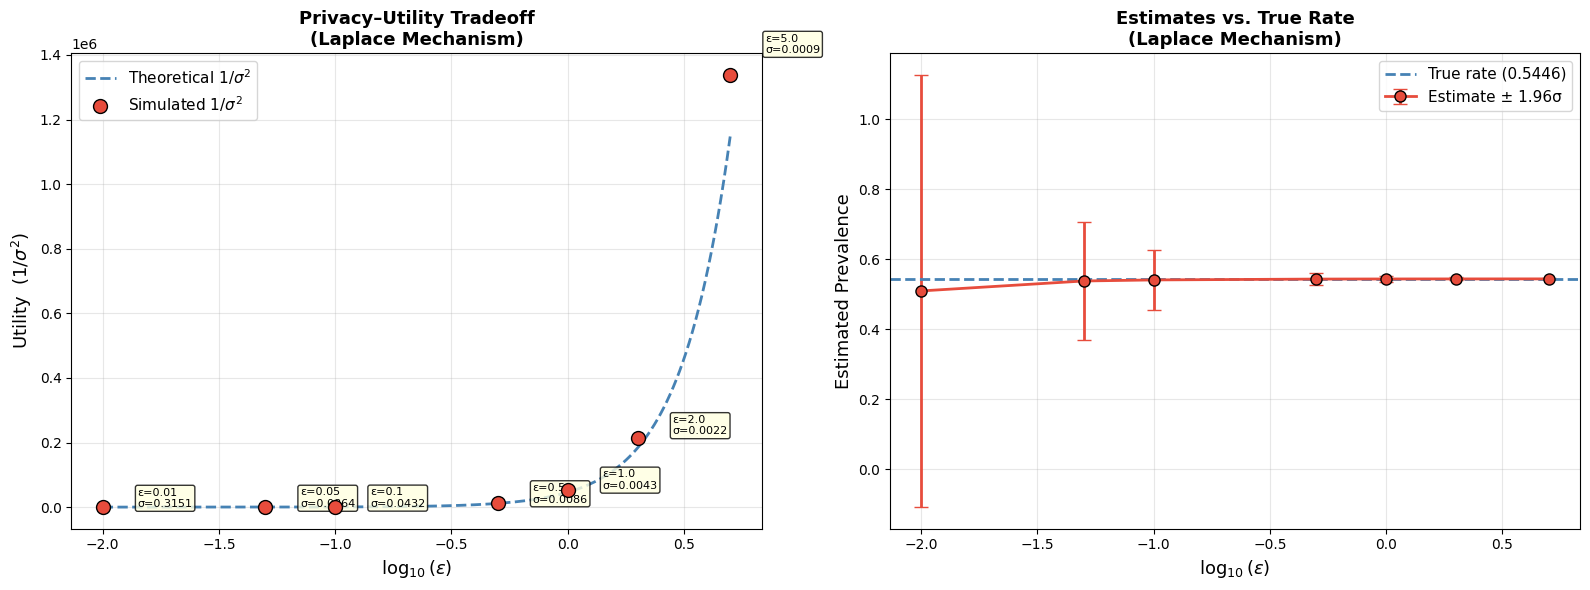

In [8]:
# TODO: call plot_laplace_tradeoff with your results
plot_laplace_tradeoff(
    epsilon_values,
    results,
    n_patients,
    disease_rate
)

## Part 5: Minimum $\varepsilon$ for a Target Accuracy

The Laplace mechanism adds noise $\eta \sim \mathrm{Lap}(\Delta f / \varepsilon)$
with standard deviation:

$$\sigma = \sqrt{2}\,\frac{\Delta f}{\varepsilon} = \frac{\sqrt{2}}{n\varepsilon},$$

because for the sample mean over data in $[0,1]$, the sensitivity is $\Delta f = 1/n$.

Here, **$m$ is the target margin of error**: we want the released noisy estimate to be within
$\pm m$ of the true mean with about 95% confidence. In this question, we set $m = 0.02$, so the
goal is for the privatized estimate to be within **$\pm 0.02$** of the true disease rate.

Using the usual normal-style 95% rule, we require:

$$1.96 \cdot \sigma \leq m
\;\Longrightarrow\;
\varepsilon \geq \frac{1.96\sqrt{2}}{n \cdot m}.$$

**Task:** Using $n =$ `n_patients` and $m = 0.02$:
1. Compute `epsilon_required` — the minimum $\varepsilon$ that satisfies this target accuracy.
2. Compute `sigma_at_required` — the theoretical noise standard deviation at `epsilon_required`.

Store both as Python **floats** (not numpy scalars).

In [9]:
# TODO: compute the minimum epsilon for the target margin of error
m = 0.02
n = n_patients

epsilon_required = (1.96 * np.sqrt(2)) / (n * m)

# TODO: compute the theoretical noise std at epsilon_required
delta_f = 1 / n
scale = delta_f / epsilon_required
sigma_at_required = np.sqrt(2) * scale

epsilon_required = float(epsilon_required)
sigma_at_required = float(sigma_at_required)

In [10]:
!jupyter nbconvert hw4.ipynb --to html --embed-images

[NbConvertApp] WARNING | pattern 'hw4.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute